In [1]:
# ================= CELL 1 — Setup =================
import os, re, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# matches your folder tree:
# cell-images-for-detecting-malaria / 1.cell-images-for-detecting-malaria / cell_images / {Parasitized, Uninfected}
DATA_ROOT = "/kaggle/input/datasets/ismailupal/cell-images-for-detecting-malaria/1.cell-images-for-detecting-malaria/cell_images"

# sanity check before moving on — run this and check the output matches expectations
assert os.path.isdir(os.path.join(DATA_ROOT, "Parasitized")), f"Parasitized folder not found under {DATA_ROOT}"
assert os.path.isdir(os.path.join(DATA_ROOT, "Uninfected")), f"Uninfected folder not found under {DATA_ROOT}"
n_para = len(os.listdir(os.path.join(DATA_ROOT, "Parasitized")))
n_unin = len(os.listdir(os.path.join(DATA_ROOT, "Uninfected")))
print(f"Parasitized: {n_para} files")
print(f"Uninfected:  {n_unin} files")

Using device: cuda
Parasitized: 13780 files
Uninfected:  13780 files


In [2]:
# ================= CELL 2 (revised) — Case-level split, fixes healthy-patient dropout =================
def get_case_id(filename):
    m = re.search(r'^C(\d+)', filename)   # case number always leads the filename
    return int(m.group(1)) if m else None

def collect_samples(root):
    samples = []
    for label, cls in enumerate(["Uninfected", "Parasitized"]):
        cls_dir = os.path.join(root, cls)
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith(".png"):
                samples.append({"path": os.path.join(cls_dir, fname),
                                 "label": label, "case": get_case_id(fname)})
    return samples

samples = collect_samples(DATA_ROOT)
n_missing = sum(1 for s in samples if s["case"] is None)
cases = sorted(set(s["case"] for s in samples if s["case"] is not None))

print(f"Total images: {len(samples)}")
print(f"Images with unparseable case ID: {n_missing}  <-- report this back to me, should be ~0 now")
print(f"Unique cases: {len(cases)}  <-- report this back to me, expect close to 200 (150 infected + 50 healthy)")

train_c, temp_c = train_test_split(cases, test_size=0.30, random_state=SEED)
val_c, test_c = train_test_split(temp_c, test_size=0.50, random_state=SEED)

def subset(samples, cset):
    return [s for s in samples if s["case"] in cset]

train_samples, val_samples, test_samples = subset(samples, set(train_c)), subset(samples, set(val_c)), subset(samples, set(test_c))
print(f"Train: {len(train_samples)} imgs / {len(train_c)} cases")
print(f"Val:   {len(val_samples)} imgs / {len(val_c)} cases")
print(f"Test:  {len(test_samples)} imgs / {len(test_c)} cases")

for name, sset in [("train", train_samples), ("val", val_samples), ("test", test_samples)]:
    pos = sum(1 for s in sset if s["label"] == 1)
    print(f"{name}: {pos} parasitized / {len(sset)-pos} uninfected")


# ================= CELL 2 (add stratification) =================
def case_type(cid, samples):
    # a case is "healthy-only" if it never contributes a parasitized image
    has_parasitized = any(s["label"] == 1 for s in samples if s["case"] == cid)
    return 1 if has_parasitized else 0

case_types = {c: case_type(c, samples) for c in cases}
strat_labels = [case_types[c] for c in cases]

train_c, temp_c = train_test_split(cases, test_size=0.30, random_state=SEED, stratify=strat_labels)
temp_strat = [case_types[c] for c in temp_c]
val_c, test_c = train_test_split(temp_c, test_size=0.50, random_state=SEED, stratify=temp_strat)

train_samples, val_samples, test_samples = subset(samples, set(train_c)), subset(samples, set(val_c)), subset(samples, set(test_c))
print(f"Train: {len(train_samples)} imgs / {len(train_c)} cases")
print(f"Val:   {len(val_samples)} imgs / {len(val_c)} cases")
print(f"Test:  {len(test_samples)} imgs / {len(test_c)} cases")
for name, sset in [("train", train_samples), ("val", val_samples), ("test", test_samples)]:
    pos = sum(1 for s in sset if s["label"] == 1)
    print(f"{name}: {pos} parasitized / {len(sset)-pos} uninfected")

Total images: 27558
Images with unparseable case ID: 0  <-- report this back to me, should be ~0 now
Unique cases: 200  <-- report this back to me, expect close to 200 (150 infected + 50 healthy)
Train: 19902 imgs / 140 cases
Val:   3144 imgs / 30 cases
Test:  4512 imgs / 30 cases
train: 10306 parasitized / 9596 uninfected
val: 1038 parasitized / 2106 uninfected
test: 2435 parasitized / 2077 uninfected
Train: 18555 imgs / 140 cases
Val:   4878 imgs / 30 cases
Test:  4125 imgs / 30 cases
train: 8974 parasitized / 9581 uninfected
val: 2756 parasitized / 2122 uninfected
test: 2049 parasitized / 2076 uninfected


In [3]:
# ================= CELL 3 — Dataset + baseline (light) augmentation =================
IMG_SIZE = 224
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

class MalariaDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples, self.transform = samples, transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        s = self.samples[idx]
        img = Image.open(s["path"]).convert("RGB")
        return self.transform(img), s["label"]

BATCH_SIZE = 32
train_loader = DataLoader(MalariaDataset(train_samples, train_tf), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(MalariaDataset(val_samples, eval_tf), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(MalariaDataset(test_samples, eval_tf), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Batches: train={len(train_loader)} val={len(val_loader)} test={len(test_loader)}")

Batches: train=580 val=153 test=129


In [4]:
# ================= CELL 4 — Train ResNet-18 baseline =================
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if train: optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train:
                loss.backward(); optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    return total_loss/total, correct/total

best_val_loss, patience_ctr = float("inf"), 0
for epoch in range(20):
    tr_loss, tr_acc = run_epoch(train_loader, True)
    val_loss, val_acc = run_epoch(val_loader, False)
    scheduler.step(val_loss)
    print(f"Epoch {epoch+1}: train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
    if val_loss < best_val_loss:
        best_val_loss, patience_ctr = val_loss, 0
        torch.save(model.state_dict(), "resnet18_baseline.pt")
        print("  -> saved best checkpoint")
    else:
        patience_ctr += 1
        if patience_ctr >= 6:
            print("Early stopping."); break

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 231MB/s]


Epoch 1: train_loss=0.1540 train_acc=0.9514 val_loss=0.1451 val_acc=0.9455
  -> saved best checkpoint
Epoch 2: train_loss=0.1276 train_acc=0.9580 val_loss=0.1281 val_acc=0.9582
  -> saved best checkpoint
Epoch 3: train_loss=0.1231 train_acc=0.9596 val_loss=0.1211 val_acc=0.9576
  -> saved best checkpoint
Epoch 4: train_loss=0.1180 train_acc=0.9610 val_loss=0.1078 val_acc=0.9621
  -> saved best checkpoint
Epoch 5: train_loss=0.1119 train_acc=0.9616 val_loss=0.1228 val_acc=0.9586
Epoch 6: train_loss=0.1105 train_acc=0.9625 val_loss=0.1069 val_acc=0.9606
  -> saved best checkpoint
Epoch 7: train_loss=0.1059 train_acc=0.9643 val_loss=0.1302 val_acc=0.9512
Epoch 8: train_loss=0.1037 train_acc=0.9653 val_loss=0.1164 val_acc=0.9625
Epoch 9: train_loss=0.0965 train_acc=0.9671 val_loss=0.1025 val_acc=0.9641
  -> saved best checkpoint
Epoch 10: train_loss=0.0955 train_acc=0.9676 val_loss=0.0989 val_acc=0.9633
  -> saved best checkpoint
Epoch 11: train_loss=0.0942 train_acc=0.9673 val_loss=0.0989

In [5]:
# ================= CELL 5 — Clean test result (report this back to me) =================
model.load_state_dict(torch.load("resnet18_baseline.pt"))
test_loss, test_acc = run_epoch(test_loader, train=False)
print(f"CLEAN TEST — loss: {test_loss:.4f}  accuracy: {test_acc:.4f}")

CLEAN TEST — loss: 0.0983  accuracy: 0.9692


In [6]:
# ================= CELL 6 — Colour interventions + severity-matched generic-corruption controls =================
import torchvision.transforms.functional as TF
from torchvision import transforms as T

class Grayscale3Ch:
    def __call__(self, img):
        return TF.to_grayscale(img, num_output_channels=3)

class HueRotate:
    def __init__(self, degrees):
        self.factor = degrees / 360.0  # torchvision expects a shift in [-0.5, 0.5]
    def __call__(self, img):
        return TF.adjust_hue(img, self.factor)

class ChannelPermute:
    def __init__(self, order):
        self.order = order
    def __call__(self, img):
        arr = np.array(img)[:, :, self.order]
        return Image.fromarray(arr)

class StrongColorJitter:
    def __init__(self):
        self.jitter = T.ColorJitter(brightness=0.4, contrast=0.3, saturation=0.5, hue=0.15)
    def __call__(self, img):
        return self.jitter(img)

class GaussianBlurControl:
    def __init__(self, kernel_size=9, sigma=2.5):
        self.blur = T.GaussianBlur(kernel_size=kernel_size, sigma=sigma)
    def __call__(self, img):
        return self.blur(img)

class GaussianNoiseControl:
    def __init__(self, std=0.08):
        self.std = std
    def __call__(self, tensor):
        return torch.clamp(tensor + torch.randn_like(tensor) * self.std, 0.0, 1.0)

# Applied before ToTensor (operate on PIL images)
PIL_INTERVENTIONS = {
    "grayscale": Grayscale3Ch(),
    "hue_30": HueRotate(30),
    "hue_60": HueRotate(60),
    "hue_90": HueRotate(90),
    "channel_bgr": ChannelPermute([2, 1, 0]),
    "channel_gbr": ChannelPermute([1, 0, 2]),
    "color_jitter_strong": StrongColorJitter(),
    "blur_control": GaussianBlurControl(),      # generic-corruption control #1
}
# Applied after ToTensor (operate on tensors)
TENSOR_INTERVENTIONS = {
    "noise_control": GaussianNoiseControl(std=0.08),  # generic-corruption control #2
}

In [7]:
# ================= CELL 7 — Evaluation function under one intervention =================
from sklearn.metrics import roc_auc_score, precision_score, f1_score, confusion_matrix

def evaluate_condition(samples, pil_intervention=None, tensor_intervention=None, img_size=224, batch_size=64):
    tf_list = [T.Resize((img_size, img_size))]
    if pil_intervention is not None:
        tf_list.append(T.Lambda(lambda img: pil_intervention(img)))
    tf_list.append(T.ToTensor())
    transform = T.Compose(tf_list)

    loader = DataLoader(MalariaDataset(samples, transform), batch_size=batch_size, shuffle=False, num_workers=2)

    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            if tensor_intervention is not None:
                imgs = tensor_intervention(imgs)
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = outputs.argmax(dim=1)
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels, all_preds, all_probs = np.array(all_labels), np.array(all_preds), np.array(all_probs)
    tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()
    try:
        auroc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auroc = np.nan

    return {
        "accuracy": (all_preds == all_labels).mean(),
        "sensitivity": tp/(tp+fn) if (tp+fn)>0 else np.nan,
        "specificity": tn/(tn+fp) if (tn+fp)>0 else np.nan,
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "f1": f1_score(all_labels, all_preds, zero_division=0),
        "auroc": auroc,
        "mean_confidence": np.mean(np.maximum(all_probs, 1 - all_probs)),
        "labels": all_labels, "probs": all_probs, "preds": all_preds,
    }

In [8]:
# ================= CELL 8 — Run the full probe on the TEST set (report the table back to me) =================
import pandas as pd, pickle

results = {"clean": evaluate_condition(test_samples)}
for name, interv in PIL_INTERVENTIONS.items():
    results[name] = evaluate_condition(test_samples, pil_intervention=interv)
for name, interv in TENSOR_INTERVENTIONS.items():
    results[name] = evaluate_condition(test_samples, tensor_intervention=interv)

clean_acc, clean_conf = results["clean"]["accuracy"], results["clean"]["mean_confidence"]
rows = [{
    "condition": name, "accuracy": r["accuracy"], "acc_drop": clean_acc - r["accuracy"],
    "sensitivity": r["sensitivity"], "specificity": r["specificity"], "auroc": r["auroc"],
    "mean_confidence": r["mean_confidence"], "conf_drop": clean_conf - r["mean_confidence"],
} for name, r in results.items()]

summary_df = pd.DataFrame(rows).sort_values("acc_drop", ascending=False)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
print(summary_df.to_string(index=False))

summary_df.to_csv("phase5_colour_intervention_results.csv", index=False)
with open("phase5_raw_predictions.pkl", "wb") as f:
    pickle.dump({name: {"labels": r["labels"], "probs": r["probs"]} for name, r in results.items()}, f)
print("\nSaved: phase5_colour_intervention_results.csv, phase5_raw_predictions.pkl")

          condition  accuracy  acc_drop  sensitivity  specificity  auroc  mean_confidence  conf_drop
        channel_gbr    0.5064    0.4628       0.0098       0.9966 0.6910           0.8396     0.1338
             hue_90    0.5350    0.4342       0.0688       0.9952 0.7403           0.8650     0.1084
          grayscale    0.6075    0.3617       0.2289       0.9812 0.8467           0.8088     0.1647
             hue_60    0.6846    0.2846       0.3777       0.9875 0.9232           0.8600     0.1134
color_jitter_strong    0.8824    0.0868       0.7950       0.9687 0.9381           0.8958     0.0776
        channel_bgr    0.9491    0.0201       0.9571       0.9412 0.9893           0.9453     0.0282
      noise_control    0.9576    0.0116       0.9644       0.9509 0.9911           0.9502     0.0232
             hue_30    0.9612    0.0080       0.9492       0.9730 0.9904           0.9600     0.0134
       blur_control    0.9685    0.0007       0.9629       0.9740 0.9934           0.9705  

In [9]:
# ================= CELL 9 — Perceptual severity check =================
# Confirms whether colour conditions are pixel-distance-comparable to the generic controls,
# or just larger perturbations in general (which would weaken the "colour is special" claim).
def mean_pixel_distance(samples, pil_intervention=None, tensor_intervention=None, n_sample=300, img_size=224):
    rng = random.Random(SEED)
    sub = rng.sample(samples, min(n_sample, len(samples)))
    tf_clean = T.Compose([T.Resize((img_size, img_size)), T.ToTensor()])
    dists = []
    for s in sub:
        img = Image.open(s["path"]).convert("RGB")
        clean_t = tf_clean(img)
        img_i = T.Resize((img_size, img_size))(img)
        if pil_intervention is not None:
            img_i = pil_intervention(img_i)
        interv_t = T.ToTensor()(img_i)
        if tensor_intervention is not None:
            interv_t = tensor_intervention(interv_t.unsqueeze(0)).squeeze(0)
        dists.append(torch.norm(clean_t - interv_t).item())
    return np.mean(dists)

print("Mean L2 pixel distance from clean (300-image sample):")
for name, interv in PIL_INTERVENTIONS.items():
    print(f"  {name:22s}: {mean_pixel_distance(test_samples, pil_intervention=interv):.3f}")
for name, interv in TENSOR_INTERVENTIONS.items():
    print(f"  {name:22s}: {mean_pixel_distance(test_samples, tensor_intervention=interv):.3f}")

Mean L2 pixel distance from clean (300-image sample):
  grayscale             : 30.980
  hue_30                : 17.283
  hue_60                : 33.498
  hue_90                : 42.101
  channel_bgr           : 48.649
  channel_gbr           : 51.077
  color_jitter_strong   : 49.686
  blur_control          : 19.034
  noise_control         : 28.719


In [10]:
# ================= CELL 10 — Get clean VALIDATION predictions (needed to fit temperature) =================
val_clean_res = evaluate_condition(val_samples)
val_labels, val_probs = val_clean_res["labels"], val_clean_res["probs"]
print(f"Val clean accuracy (sanity check vs training log): {val_clean_res['accuracy']:.4f}")

Val clean accuracy (sanity check vs training log): 0.9711


In [11]:
# ================= CELL 11 — Fit temperature scaling on clean validation set =================
def prob_to_logit(p, eps=1e-7):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

val_logits = torch.tensor(prob_to_logit(val_probs), dtype=torch.float32)
val_y = torch.tensor(val_labels, dtype=torch.float32)

T_param = torch.nn.Parameter(torch.ones(1))
optimizer_T = torch.optim.Adam([T_param], lr=0.01)
bce = torch.nn.BCEWithLogitsLoss()
for _ in range(300):
    optimizer_T.zero_grad()
    loss = bce(val_logits / T_param, val_y)
    loss.backward()
    optimizer_T.step()

T_fitted = T_param.item()
print(f"Fitted temperature T = {T_fitted:.4f}  (T>1 => model was overconfident on clean val data)")

Fitted temperature T = 1.0610  (T>1 => model was overconfident on clean val data)


In [12]:
# ================= CELL 12 — ECE / Brier utilities + full comparison table =================
def expected_calibration_error(labels, probs, preds, n_bins=15):
    confidences = np.maximum(probs, 1 - probs)
    correct = (preds == labels).astype(float)
    edges = np.linspace(0, 1, n_bins + 1)
    ece, bin_stats = 0.0, []
    for i in range(n_bins):
        lo, hi = edges[i], edges[i+1]
        mask = (confidences > lo) & (confidences <= hi) if i > 0 else (confidences >= lo) & (confidences <= hi)
        if mask.sum() == 0:
            bin_stats.append((lo, hi, np.nan, np.nan, 0)); continue
        bin_acc, bin_conf = correct[mask].mean(), confidences[mask].mean()
        ece += (mask.sum()/len(labels)) * abs(bin_acc - bin_conf)
        bin_stats.append((lo, hi, bin_acc, bin_conf, mask.sum()))
    return ece, bin_stats

def brier_score(labels, probs):
    return np.mean((probs - labels) ** 2)

def apply_temperature(probs, T, eps=1e-7):
    z = prob_to_logit(probs, eps)
    return 1 / (1 + np.exp(-z / T))

with open("phase5_raw_predictions.pkl", "rb") as f:
    saved = pickle.load(f)

calib_rows = []
for name, d in saved.items():
    labels, probs = d["labels"], d["probs"]
    preds = (probs >= 0.5).astype(int)
    ece_raw, _ = expected_calibration_error(labels, probs, preds)
    probs_T = apply_temperature(probs, T_fitted)
    ece_T, _ = expected_calibration_error(labels, probs_T, preds)
    calib_rows.append({
        "condition": name, "accuracy": (preds==labels).mean(),
        "ece_raw": ece_raw, "brier_raw": brier_score(labels, probs),
        "ece_temp_scaled": ece_T, "brier_temp_scaled": brier_score(labels, probs_T),
    })

calib_df = pd.DataFrame(calib_rows).sort_values("ece_raw", ascending=False)
print(calib_df.to_string(index=False))
calib_df.to_csv("phase6_calibration_results.csv", index=False)

          condition  accuracy  ece_raw  brier_raw  ece_temp_scaled  brier_temp_scaled
        channel_gbr    0.5064   0.3332     0.3395           0.3219             0.3312
             hue_90    0.5350   0.3311     0.3337           0.3203             0.3253
          grayscale    0.6075   0.2012     0.2481           0.1931             0.2440
             hue_60    0.6846   0.1769     0.2092           0.1696             0.2054
color_jitter_strong    0.8824   0.0385     0.0921           0.0383             0.0921
      noise_control    0.9576   0.0128     0.0335           0.0162             0.0338
        channel_bgr    0.9491   0.0120     0.0388           0.0131             0.0390
              clean    0.9692   0.0108     0.0254           0.0073             0.0253
       blur_control    0.9685   0.0084     0.0257           0.0080             0.0257
             hue_30    0.9612   0.0075     0.0302           0.0076             0.0303


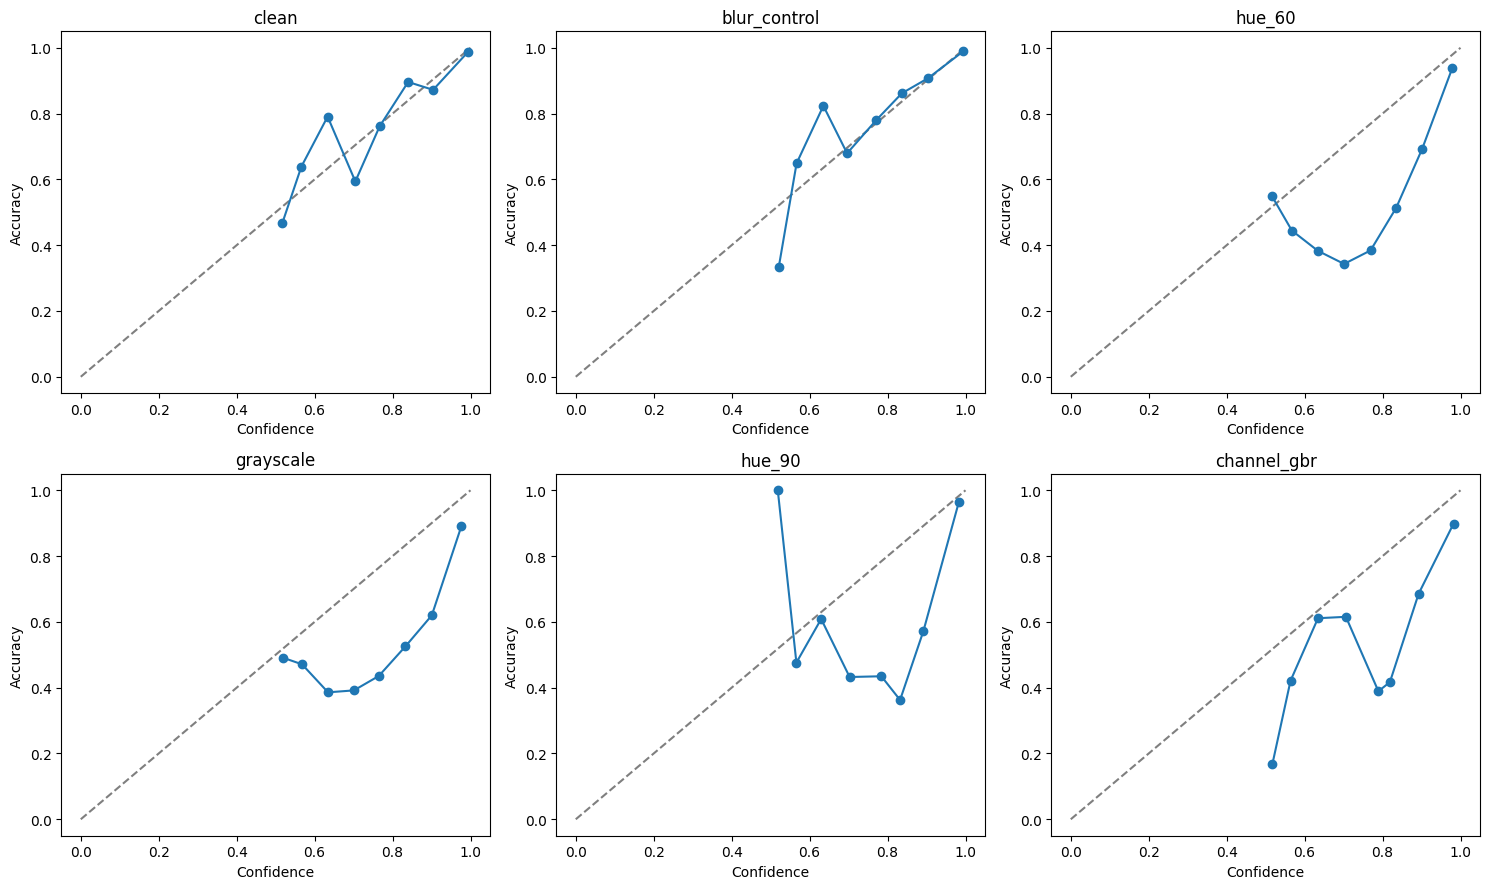

In [13]:
# ================= CELL 13 — Reliability diagrams for the key conditions =================
import matplotlib.pyplot as plt
key_conditions = ["clean", "blur_control", "hue_60", "grayscale", "hue_90", "channel_gbr"]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, name in zip(axes.flat, key_conditions):
    labels, probs = saved[name]["labels"], saved[name]["probs"]
    preds = (probs >= 0.5).astype(int)
    _, bin_stats = expected_calibration_error(labels, probs, preds)
    confs = [b[3] for b in bin_stats if not np.isnan(b[3])]
    accs = [b[2] for b in bin_stats if not np.isnan(b[2])]
    ax.plot([0,1],[0,1],'k--', alpha=0.5)
    ax.plot(confs, accs, 'o-')
    ax.set_title(name); ax.set_xlabel("Confidence"); ax.set_ylabel("Accuracy")
plt.tight_layout()
plt.savefig("phase6_reliability_diagrams.png", dpi=150)
plt.show()

In [14]:
# ================= CELL 14 (optional) — Per-channel ablation =================
class ZeroChannel:
    def __init__(self, idx):
        self.idx = idx
    def __call__(self, img):
        arr = np.array(img).copy()
        arr[:, :, self.idx] = 0
        return Image.fromarray(arr)

for name, ch in [("zero_R", 0), ("zero_G", 1), ("zero_B", 2)]:
    r = evaluate_condition(test_samples, pil_intervention=ZeroChannel(ch))
    ece, _ = expected_calibration_error(r["labels"], r["probs"], r["preds"])
    print(f"{name}: acc={r['accuracy']:.4f} sens={r['sensitivity']:.4f} spec={r['specificity']:.4f} ece={ece:.4f}")

zero_R: acc=0.5040 sens=0.0015 spec=1.0000 ece=0.4244
zero_G: acc=0.5033 sens=0.0000 spec=1.0000 ece=0.4949
zero_B: acc=0.5845 sens=0.1650 spec=0.9986 ece=0.2044


In [15]:
# ================= CELL 15 — Replication check across two more seeds =================
def train_baseline(seed, epochs=20, patience=6):
    torch.manual_seed(seed)
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, 2)
    m = m.to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.1, patience=2)
    crit = nn.CrossEntropyLoss()

    def epoch_pass(loader, train):
        m.train() if train else m.eval()
        tot_loss, correct, total = 0.0, 0, 0
        with torch.set_grad_enabled(train):
            for imgs, labels in loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                if train: opt.zero_grad()
                out = m(imgs)
                loss = crit(out, labels)
                if train:
                    loss.backward(); opt.step()
                tot_loss += loss.item()*imgs.size(0)
                correct += (out.argmax(1)==labels).sum().item()
                total += imgs.size(0)
        return tot_loss/total, correct/total

    best_val, ctr = float("inf"), 0
    ckpt_name = f"resnet18_seed{seed}.pt"
    for ep in range(epochs):
        tr_loss, tr_acc = epoch_pass(train_loader, True)
        val_loss, val_acc = epoch_pass(val_loader, False)
        sched.step(val_loss)
        print(f"  seed {seed} epoch {ep+1}: val_acc={val_acc:.4f}")
        if val_loss < best_val:
            best_val, ctr = val_loss, 0
            torch.save(m.state_dict(), ckpt_name)
        else:
            ctr += 1
            if ctr >= patience: break
    m.load_state_dict(torch.load(ckpt_name))
    return m

KEY_CHECKS = {
    "clean": (None, None),
    "grayscale": (PIL_INTERVENTIONS["grayscale"], None),
    "hue_90": (PIL_INTERVENTIONS["hue_90"], None),
    "channel_bgr": (PIL_INTERVENTIONS["channel_bgr"], None),
    "channel_gbr": (PIL_INTERVENTIONS["channel_gbr"], None),
    "blur_control": (PIL_INTERVENTIONS["blur_control"], None),
    "noise_control": (None, TENSOR_INTERVENTIONS["noise_control"]),
}

replication_rows = []
for seed in [1, 7]:
    print(f"\n--- Training replication seed {seed} ---")
    model = train_baseline(seed)   # reassigns the global `model` used inside evaluate_condition()
    for name, (pil_i, tensor_i) in KEY_CHECKS.items():
        r = evaluate_condition(test_samples, pil_intervention=pil_i, tensor_intervention=tensor_i)
        replication_rows.append({"seed": seed, "condition": name,
                                  "accuracy": r["accuracy"], "sensitivity": r["sensitivity"],
                                  "specificity": r["specificity"]})

rep_df = pd.DataFrame(replication_rows)
print("\nSensitivity by condition and seed:")
print(rep_df.pivot(index="condition", columns="seed", values="sensitivity"))
rep_df.to_csv("phase5_replication_check.csv", index=False)

# IMPORTANT: restore the original seed-42 baseline before doing anything else —
# `model` currently points to the seed=7 network, not your main baseline.
model.load_state_dict(torch.load("resnet18_baseline.pt"))
print("\nRestored original baseline checkpoint into `model`.")


--- Training replication seed 1 ---
  seed 1 epoch 1: val_acc=0.9586
  seed 1 epoch 2: val_acc=0.9594
  seed 1 epoch 3: val_acc=0.9561
  seed 1 epoch 4: val_acc=0.9602
  seed 1 epoch 5: val_acc=0.9545
  seed 1 epoch 6: val_acc=0.9541
  seed 1 epoch 7: val_acc=0.9596
  seed 1 epoch 8: val_acc=0.9627
  seed 1 epoch 9: val_acc=0.9615
  seed 1 epoch 10: val_acc=0.9639
  seed 1 epoch 11: val_acc=0.9676
  seed 1 epoch 12: val_acc=0.9656
  seed 1 epoch 13: val_acc=0.9672
  seed 1 epoch 14: val_acc=0.9672
  seed 1 epoch 15: val_acc=0.9592
  seed 1 epoch 16: val_acc=0.9692
  seed 1 epoch 17: val_acc=0.9725
  seed 1 epoch 18: val_acc=0.9727
  seed 1 epoch 19: val_acc=0.9731
  seed 1 epoch 20: val_acc=0.9701

--- Training replication seed 7 ---
  seed 7 epoch 1: val_acc=0.9559
  seed 7 epoch 2: val_acc=0.9561
  seed 7 epoch 3: val_acc=0.9582
  seed 7 epoch 4: val_acc=0.9590
  seed 7 epoch 5: val_acc=0.9590
  seed 7 epoch 6: val_acc=0.9635
  seed 7 epoch 7: val_acc=0.9598
  seed 7 epoch 8: val_ac

In [16]:
# ================= CELL 16 — Colour-aware augmented training set =================
train_tf_augmented = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.RandomApply([T.Grayscale(num_output_channels=3)], p=0.25),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.4, hue=0.5),
    T.ToTensor(),
])
train_loader_aug = DataLoader(MalariaDataset(train_samples, train_tf_augmented),
                               batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

In [17]:
# ================= CELL 17 — Train the mitigated (colour-aware) model, same seed as baseline =================
torch.manual_seed(SEED)
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)
criterion = nn.CrossEntropyLoss()

best_val_loss, patience_ctr = float("inf"), 0
for epoch in range(20):
    tr_loss, tr_acc = run_epoch(train_loader_aug, True)
    val_loss, val_acc = run_epoch(val_loader, False)
    scheduler.step(val_loss)
    print(f"Epoch {epoch+1}: train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
    if val_loss < best_val_loss:
        best_val_loss, patience_ctr = val_loss, 0
        torch.save(model.state_dict(), "resnet18_mitigated.pt")
        print("  -> saved best checkpoint")
    else:
        patience_ctr += 1
        if patience_ctr >= 6:
            print("Early stopping."); break

Epoch 1: train_loss=0.1902 train_acc=0.9365 val_loss=0.1788 val_acc=0.9303
  -> saved best checkpoint
Epoch 2: train_loss=0.1482 train_acc=0.9495 val_loss=0.1464 val_acc=0.9461
  -> saved best checkpoint
Epoch 3: train_loss=0.1466 train_acc=0.9516 val_loss=0.1602 val_acc=0.9364
Epoch 4: train_loss=0.1412 train_acc=0.9535 val_loss=0.1470 val_acc=0.9414
Epoch 5: train_loss=0.1313 train_acc=0.9563 val_loss=0.1290 val_acc=0.9545
  -> saved best checkpoint
Epoch 6: train_loss=0.1328 train_acc=0.9549 val_loss=0.1739 val_acc=0.9276
Epoch 7: train_loss=0.1281 train_acc=0.9574 val_loss=0.1370 val_acc=0.9475
Epoch 8: train_loss=0.1250 train_acc=0.9568 val_loss=0.1300 val_acc=0.9522
Epoch 9: train_loss=0.1000 train_acc=0.9645 val_loss=0.0999 val_acc=0.9608
  -> saved best checkpoint
Epoch 10: train_loss=0.0961 train_acc=0.9663 val_loss=0.0975 val_acc=0.9639
  -> saved best checkpoint
Epoch 11: train_loss=0.0930 train_acc=0.9672 val_loss=0.0930 val_acc=0.9645
  -> saved best checkpoint
Epoch 12: t

In [18]:
# ================= CELL 18 — Re-run full probe + calibration on the mitigated model =================
model.load_state_dict(torch.load("resnet18_mitigated.pt"))

mitigated_results = {"clean": evaluate_condition(test_samples)}
for name, interv in PIL_INTERVENTIONS.items():
    mitigated_results[name] = evaluate_condition(test_samples, pil_intervention=interv)
for name, interv in TENSOR_INTERVENTIONS.items():
    mitigated_results[name] = evaluate_condition(test_samples, tensor_intervention=interv)

rows_m = []
for name, r in mitigated_results.items():
    ece_m, _ = expected_calibration_error(r["labels"], r["probs"], r["preds"])
    rows_m.append({"condition": name, "accuracy": r["accuracy"], "sensitivity": r["sensitivity"],
                    "specificity": r["specificity"], "ece": ece_m, "mean_confidence": r["mean_confidence"]})

mitigated_df = pd.DataFrame(rows_m).sort_values("accuracy")
print("=== MITIGATED MODEL ===")
print(mitigated_df.to_string(index=False))
mitigated_df.to_csv("phase7_mitigated_results.csv", index=False)
with open("phase7_mitigated_raw_predictions.pkl", "wb") as f:
    pickle.dump({name: {"labels": r["labels"], "probs": r["probs"]} for name, r in mitigated_results.items()}, f)

=== MITIGATED MODEL ===
          condition  accuracy  sensitivity  specificity    ece  mean_confidence
       blur_control    0.7566       0.9985       0.5178 0.1469           0.9035
        channel_bgr    0.9615       0.9561       0.9668 0.0055           0.9662
      noise_control    0.9615       0.9639       0.9591 0.0120           0.9513
          grayscale    0.9617       0.9551       0.9682 0.0064           0.9630
        channel_gbr    0.9624       0.9590       0.9658 0.0055           0.9663
             hue_60    0.9629       0.9605       0.9653 0.0037           0.9625
             hue_90    0.9629       0.9571       0.9687 0.0055           0.9603
              clean    0.9644       0.9610       0.9677 0.0054           0.9660
color_jitter_strong    0.9644       0.9629       0.9658 0.0034           0.9647
             hue_30    0.9656       0.9649       0.9663 0.0056           0.9653


In [19]:
# ================= CELL 19 — Baseline vs mitigated, side by side =================
baseline_summary = pd.read_csv("phase5_colour_intervention_results.csv")
baseline_calib = pd.read_csv("phase6_calibration_results.csv")

rows_compare = []
for cond in mitigated_df["condition"]:
    b = baseline_summary[baseline_summary["condition"] == cond].iloc[0]
    b_ece = baseline_calib[baseline_calib["condition"] == cond].iloc[0]
    m = mitigated_df[mitigated_df["condition"] == cond].iloc[0]
    rows_compare.append({
        "condition": cond,
        "acc_base": b["accuracy"], "acc_mit": m["accuracy"],
        "sens_base": b["sensitivity"], "sens_mit": m["sensitivity"],
        "ece_base": b_ece["ece_raw"], "ece_mit": m["ece"],
    })
compare_df = pd.DataFrame(rows_compare)
print(compare_df.to_string(index=False))
compare_df.to_csv("phase7_baseline_vs_mitigated_comparison.csv", index=False)

          condition  acc_base  acc_mit  sens_base  sens_mit  ece_base  ece_mit
       blur_control    0.9685   0.7566     0.9629    0.9985    0.0084   0.1469
        channel_bgr    0.9491   0.9615     0.9571    0.9561    0.0120   0.0055
      noise_control    0.9576   0.9615     0.9644    0.9639    0.0128   0.0120
          grayscale    0.6075   0.9617     0.2289    0.9551    0.2012   0.0064
        channel_gbr    0.5064   0.9624     0.0098    0.9590    0.3332   0.0055
             hue_60    0.6846   0.9629     0.3777    0.9605    0.1769   0.0037
             hue_90    0.5350   0.9629     0.0688    0.9571    0.3311   0.0055
              clean    0.9692   0.9644     0.9658    0.9610    0.0108   0.0054
color_jitter_strong    0.8824   0.9644     0.7950    0.9629    0.0385   0.0034
             hue_30    0.9612   0.9656     0.9492    0.9649    0.0075   0.0056


In [20]:
# ================= CELL 20 — Replicate the MITIGATED model, check the blur regression =================
def train_mitigated(seed, epochs=20, patience=6):
    torch.manual_seed(seed)
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, 2)
    m = m.to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.1, patience=2)
    crit = nn.CrossEntropyLoss()

    def epoch_pass(loader, train):
        m.train() if train else m.eval()
        tot_loss, correct, total = 0.0, 0, 0
        with torch.set_grad_enabled(train):
            for imgs, labels in loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                if train: opt.zero_grad()
                out = m(imgs)
                loss = crit(out, labels)
                if train:
                    loss.backward(); opt.step()
                tot_loss += loss.item()*imgs.size(0)
                correct += (out.argmax(1)==labels).sum().item()
                total += imgs.size(0)
        return tot_loss/total, correct/total

    best_val, ctr = float("inf"), 0
    ckpt = f"resnet18_mitigated_seed{seed}.pt"
    for ep in range(epochs):
        tr_loss, tr_acc = epoch_pass(train_loader_aug, True)
        val_loss, val_acc = epoch_pass(val_loader, False)
        sched.step(val_loss)
        print(f"  seed {seed} epoch {ep+1}: val_acc={val_acc:.4f}")
        if val_loss < best_val:
            best_val, ctr = val_loss, 0
            torch.save(m.state_dict(), ckpt)
        else:
            ctr += 1
            if ctr >= patience: break
    m.load_state_dict(torch.load(ckpt))
    return m

CHECK_CONDITIONS = {
    "clean": (None, None), "grayscale": (PIL_INTERVENTIONS["grayscale"], None),
    "hue_90": (PIL_INTERVENTIONS["hue_90"], None), "channel_gbr": (PIL_INTERVENTIONS["channel_gbr"], None),
    "channel_bgr": (PIL_INTERVENTIONS["channel_bgr"], None), "blur_control": (PIL_INTERVENTIONS["blur_control"], None),
    "noise_control": (None, TENSOR_INTERVENTIONS["noise_control"]),
}

mit_rep_rows = []
for seed in [1, 7]:
    print(f"\n--- Mitigated replication seed {seed} ---")
    model = train_mitigated(seed)
    for name, (pil_i, tensor_i) in CHECK_CONDITIONS.items():
        r = evaluate_condition(test_samples, pil_intervention=pil_i, tensor_intervention=tensor_i)
        mit_rep_rows.append({"seed": seed, "condition": name, "accuracy": r["accuracy"],
                              "sensitivity": r["sensitivity"], "specificity": r["specificity"]})

mit_rep_df = pd.DataFrame(mit_rep_rows)
print("\nSpecificity by condition and seed (mitigated model) — watch blur_control:")
print(mit_rep_df.pivot(index="condition", columns="seed", values="specificity"))
print("\nSensitivity by condition and seed (mitigated model):")
print(mit_rep_df.pivot(index="condition", columns="seed", values="sensitivity"))
mit_rep_df.to_csv("phase7_mitigated_replication_check.csv", index=False)

model.load_state_dict(torch.load("resnet18_mitigated.pt"))
print("\nRestored original mitigated (seed 42) checkpoint into `model`.")


--- Mitigated replication seed 1 ---
  seed 1 epoch 1: val_acc=0.9410
  seed 1 epoch 2: val_acc=0.9446
  seed 1 epoch 3: val_acc=0.9531
  seed 1 epoch 4: val_acc=0.9467
  seed 1 epoch 5: val_acc=0.9508
  seed 1 epoch 6: val_acc=0.9510
  seed 1 epoch 7: val_acc=0.9580
  seed 1 epoch 8: val_acc=0.9613
  seed 1 epoch 9: val_acc=0.9594
  seed 1 epoch 10: val_acc=0.9623
  seed 1 epoch 11: val_acc=0.9651
  seed 1 epoch 12: val_acc=0.9651
  seed 1 epoch 13: val_acc=0.9664
  seed 1 epoch 14: val_acc=0.9651
  seed 1 epoch 15: val_acc=0.9672
  seed 1 epoch 16: val_acc=0.9682
  seed 1 epoch 17: val_acc=0.9682
  seed 1 epoch 18: val_acc=0.9688
  seed 1 epoch 19: val_acc=0.9678
  seed 1 epoch 20: val_acc=0.9690

--- Mitigated replication seed 7 ---
  seed 7 epoch 1: val_acc=0.9430
  seed 7 epoch 2: val_acc=0.9340
  seed 7 epoch 3: val_acc=0.9440
  seed 7 epoch 4: val_acc=0.9510
  seed 7 epoch 5: val_acc=0.9510
  seed 7 epoch 6: val_acc=0.9473
  seed 7 epoch 7: val_acc=0.9549
  seed 7 epoch 8: val_

In [21]:
# ================= CELL 21 — Colour + mild blur augmented training set (v2 mitigation) =================
train_tf_augmented_v2 = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.RandomApply([T.Grayscale(num_output_channels=3)], p=0.25),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.4, hue=0.5),
    T.RandomApply([T.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))], p=0.3),  # mild, not as severe as the test-time blur_control
    T.ToTensor(),
])
train_loader_aug_v2 = DataLoader(MalariaDataset(train_samples, train_tf_augmented_v2),
                                  batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

In [22]:
# ================= CELL 22 — Generalized training function (reused across all variants/seeds) =================
def train_variant(seed, loader, epochs=20, patience=6, ckpt_prefix="model"):
    torch.manual_seed(seed)
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, 2)
    m = m.to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.1, patience=2)
    crit = nn.CrossEntropyLoss()

    def epoch_pass(dloader, train):
        m.train() if train else m.eval()
        tot_loss, correct, total = 0.0, 0, 0
        with torch.set_grad_enabled(train):
            for imgs, labels in dloader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                if train: opt.zero_grad()
                out = m(imgs)
                loss = crit(out, labels)
                if train:
                    loss.backward(); opt.step()
                tot_loss += loss.item()*imgs.size(0)
                correct += (out.argmax(1)==labels).sum().item()
                total += imgs.size(0)
        return tot_loss/total, correct/total

    best_val, ctr = float("inf"), 0
    ckpt = f"{ckpt_prefix}_seed{seed}.pt"
    for ep in range(epochs):
        tr_loss, tr_acc = epoch_pass(loader, True)
        val_loss, val_acc = epoch_pass(val_loader, False)
        sched.step(val_loss)
        print(f"  seed {seed} epoch {ep+1}: val_acc={val_acc:.4f}")
        if val_loss < best_val:
            best_val, ctr = val_loss, 0
            torch.save(m.state_dict(), ckpt)
        else:
            ctr += 1
            if ctr >= patience: break
    m.load_state_dict(torch.load(ckpt))
    return m

In [23]:
# ================= CELL 23 — Train v2 across all 3 seeds and evaluate =================
v2_rows = []
for seed in [42, 1, 7]:
    print(f"\n--- Training colour+blur variant, seed {seed} ---")
    model = train_variant(seed, train_loader_aug_v2, ckpt_prefix="resnet18_v2")
    for name, (pil_i, tensor_i) in CHECK_CONDITIONS.items():
        r = evaluate_condition(test_samples, pil_intervention=pil_i, tensor_intervention=tensor_i)
        v2_rows.append({"seed": seed, "condition": name, "accuracy": r["accuracy"],
                         "sensitivity": r["sensitivity"], "specificity": r["specificity"]})

v2_df = pd.DataFrame(v2_rows)
print("\n=== V2 (colour+blur) specificity by condition and seed ===")
print(v2_df.pivot(index="condition", columns="seed", values="specificity"))
print("\n=== V2 (colour+blur) sensitivity by condition and seed ===")
print(v2_df.pivot(index="condition", columns="seed",  values="sensitivity"))
v2_df.to_csv("phase7_v2_colour_blur_replication.csv", index=False)


--- Training colour+blur variant, seed 42 ---
  seed 42 epoch 1: val_acc=0.9422
  seed 42 epoch 2: val_acc=0.9496
  seed 42 epoch 3: val_acc=0.9309
  seed 42 epoch 4: val_acc=0.9440
  seed 42 epoch 5: val_acc=0.9549
  seed 42 epoch 6: val_acc=0.9494
  seed 42 epoch 7: val_acc=0.9326
  seed 42 epoch 8: val_acc=0.9572
  seed 42 epoch 9: val_acc=0.9590
  seed 42 epoch 10: val_acc=0.9528
  seed 42 epoch 11: val_acc=0.9549
  seed 42 epoch 12: val_acc=0.9637
  seed 42 epoch 13: val_acc=0.9539
  seed 42 epoch 14: val_acc=0.9623
  seed 42 epoch 15: val_acc=0.9582
  seed 42 epoch 16: val_acc=0.9567
  seed 42 epoch 17: val_acc=0.9369
  seed 42 epoch 18: val_acc=0.9606
  seed 42 epoch 19: val_acc=0.9592
  seed 42 epoch 20: val_acc=0.9608

--- Training colour+blur variant, seed 1 ---
  seed 1 epoch 1: val_acc=0.9500
  seed 1 epoch 2: val_acc=0.9352
  seed 1 epoch 3: val_acc=0.9289
  seed 1 epoch 4: val_acc=0.9477
  seed 1 epoch 5: val_acc=0.9557
  seed 1 epoch 6: val_acc=0.9506
  seed 1 epoch 7: 

In [24]:
# ================= CELL 24 — Three-way comparison: baseline vs colour-only vs colour+blur =================
baseline_seed42 = pd.read_csv("phase5_colour_intervention_results.csv")[["condition","accuracy","sensitivity","specificity"]]
baseline_seed42["seed"] = 42
baseline_full = pd.concat([baseline_seed42, pd.read_csv("phase5_replication_check.csv")], ignore_index=True)

v1_seed42 = pd.read_csv("phase7_mitigated_results.csv")[["condition","accuracy","sensitivity","specificity"]]
v1_seed42["seed"] = 42
v1_full = pd.concat([v1_seed42, pd.read_csv("phase7_mitigated_replication_check.csv")], ignore_index=True)

KEY_ROWS = ["clean", "grayscale", "hue_90", "channel_gbr", "blur_control"]

def summarize(df, label):
    sub = df[df["condition"].isin(KEY_ROWS)]
    g = sub.groupby("condition")[["sensitivity","specificity"]].agg(["mean","std"])
    g.columns = ["_".join(c) for c in g.columns]
    g["variant"] = label
    return g.reset_index()

summary_all = pd.concat([summarize(baseline_full,"baseline"), summarize(v1_full,"colour_only"), summarize(v2_df,"colour_plus_blur")])
pivot_sens = summary_all.pivot(index="condition", columns="variant", values="sensitivity_mean")[["baseline","colour_only","colour_plus_blur"]].loc[KEY_ROWS]
pivot_spec = summary_all.pivot(index="condition", columns="variant", values="specificity_mean")[["baseline","colour_only","colour_plus_blur"]].loc[KEY_ROWS]

print("=== Mean SENSITIVITY across 3 seeds ===")
print(pivot_sens.round(4))
print("\n=== Mean SPECIFICITY across 3 seeds ===")
print(pivot_spec.round(4))
summary_all.to_csv("phase7_three_way_comparison.csv", index=False)

=== Mean SENSITIVITY across 3 seeds ===
variant       baseline  colour_only  colour_plus_blur
condition                                            
clean           0.9613       0.9593            0.9548
grayscale       0.1428       0.9593            0.9579
hue_90          0.0604       0.9597            0.9535
channel_gbr     0.0072       0.9582            0.9514
blur_control    0.9580       0.9863            0.9619

=== Mean SPECIFICITY across 3 seeds ===
variant       baseline  colour_only  colour_plus_blur
condition                                            
clean           0.9740       0.9684            0.9690
grayscale       0.9838       0.9656            0.9682
hue_90          0.9963       0.9668            0.9701
channel_gbr     0.9982       0.9669            0.9722
blur_control    0.9750       0.6599            0.9396


In [25]:
# ================= CELL 25 — Download the Tanzania cross-site dataset =================
# Requires Internet: On in Kaggle notebook settings (Settings -> Internet).
!curl -L -o /kaggle/working/tanzania_malaria.zip \
  "https://dataverse.harvard.edu/api/access/dataset/:persistentId/?persistentId=doi:10.7910/DVN/O2WVWA"

import os
print(f"Downloaded file size: {os.path.getsize('/kaggle/working/tanzania_malaria.zip') / 1e6:.1f} MB")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 2842M    0 2842M    0     0  19.6M      0 --:--:--  0:02:24 --:--:-- 20.8M
Downloaded file size: 2980.3 MB


In [26]:
# ================= CELL 26 — Unzip and inspect structure (don't assume folder names yet) =================
import zipfile

with zipfile.ZipFile("/kaggle/working/tanzania_malaria.zip", "r") as z:
    names = z.namelist()
    print(f"Total entries in zip: {len(names)}")
    print("\nFirst 20 entries:")
    for n in names[:20]:
        print(" ", n)
    z.extractall("/kaggle/working/tanzania_raw")

# Walk the extracted structure to see actual folder/label names
for root, dirs, files in os.walk("/kaggle/working/tanzania_raw"):
    depth = root.replace("/kaggle/working/tanzania_raw", "").count(os.sep)
    if depth <= 2:
        img_count = sum(1 for f in files if f.lower().endswith((".png",".jpg",".jpeg",".tif",".tiff")))
        print(f"{'  '*depth}{os.path.basename(root) or 'ROOT'}  ({img_count} image files, {len(dirs)} subfolders)")

Total entries in zip: 4

First 20 entries:
  Thick_Infected.zip
  Thick_Uninfected.zip
  Thin_Infected.zip
  Thin_Uninfected.zip
tanzania_raw  (0 image files, 0 subfolders)


In [27]:
# ================= CELL 27 — Extract only the thin-smear subset we actually need =================
import zipfile, os

NEEDED = ["Thin_Infected.zip", "Thin_Uninfected.zip"]

for fname in NEEDED:
    src = f"/kaggle/working/tanzania_raw/{fname}"
    dst = f"/kaggle/working/tanzania_thin/{fname.replace('.zip','')}"
    os.makedirs(dst, exist_ok=True)
    with zipfile.ZipFile(src, "r") as z:
        inner_names = z.namelist()
        print(f"{fname}: {len(inner_names)} entries, first 5:")
        for n in inner_names[:5]:
            print("  ", n)
        z.extractall(dst)

# Inspect what actually landed on disk (nested folders inside the inner zip are common)
for root, dirs, files in os.walk("/kaggle/working/tanzania_thin"):
    depth = root.replace("/kaggle/working/tanzania_thin", "").count(os.sep)
    if depth <= 2:
        img_count = sum(1 for f in files if f.lower().endswith((".png",".jpg",".jpeg",".tif",".tiff",".bmp")))
        print(f"{'  '*depth}{os.path.basename(root) or 'ROOT'}  ({img_count} images, {len(dirs)} subfolders)")

Thin_Infected.zip: 1064 entries, first 5:
   Thin_Infected/Image2170.jpg
   Thin_Infected/Image2172.jpg
   Thin_Infected/Image2173.jpg
   Thin_Infected/Image2174.jpg
   Thin_Infected/Image2175.jpg
Thin_Uninfected.zip: 270 entries, first 5:
   Thin_Uninfected/Image3275.jpg
   Thin_Uninfected/Image3276.jpg
   Thin_Uninfected/Image3277.jpg
   Thin_Uninfected/Image3278.jpg
   Thin_Uninfected/Image3279.jpg
tanzania_thin  (0 images, 2 subfolders)
  Thin_Infected  (0 images, 1 subfolders)
    Thin_Infected  (1064 images, 0 subfolders)
  Thin_Uninfected  (0 images, 1 subfolders)
    Thin_Uninfected  (270 images, 0 subfolders)


In [28]:
# ================= CELL 28 — Check image dimensions before assuming single-cell crops =================
from PIL import Image
import numpy as np

INFECTED_DIR = "/kaggle/working/tanzania_thin/Thin_Infected/Thin_Infected"
UNINFECTED_DIR = "/kaggle/working/tanzania_thin/Thin_Uninfected/Thin_Uninfected"

sample_files = os.listdir(INFECTED_DIR)[:10] + os.listdir(UNINFECTED_DIR)[:10]
sample_dirs = [INFECTED_DIR]*10 + [UNINFECTED_DIR]*10

sizes = []
for d, f in zip(sample_dirs, sample_files):
    img = Image.open(os.path.join(d, f))
    sizes.append(img.size)  # (width, height)
    print(f"{f}: {img.size}  mode={img.mode}")

sizes = np.array(sizes)
print(f"\nWidth  range: {sizes[:,0].min()}-{sizes[:,0].max()}, mean={sizes[:,0].mean():.0f}")
print(f"Height range: {sizes[:,1].min()}-{sizes[:,1].max()}, mean={sizes[:,1].mean():.0f}")

Image2683.jpg: (3840, 2160)  mode=RGB
Image3055.jpg: (3840, 2160)  mode=RGB
Image2522.jpg: (3840, 2160)  mode=RGB
Image2689.jpg: (3840, 2160)  mode=RGB
Image2555.jpg: (3840, 2160)  mode=RGB
Image2319.jpg: (3840, 2160)  mode=RGB
Image3158.jpg: (3840, 2160)  mode=RGB
Image2692.jpg: (3840, 2160)  mode=RGB
Image2690.jpg: (3840, 2160)  mode=RGB
Image2424.jpg: (3840, 2160)  mode=RGB
Image3353.jpg: (3840, 2160)  mode=RGB
Image3386.jpg: (1640, 922)  mode=RGBA
Image3331.jpg: (3840, 2160)  mode=RGB
Image3470.jpg: (1640, 922)  mode=RGBA
Image3417.jpg: (1640, 922)  mode=RGBA
Image3485.jpg: (1640, 922)  mode=RGBA
Image3526.jpg: (1640, 922)  mode=RGBA
Image3438.jpg: (1640, 922)  mode=RGBA
Image3531.jpg: (1640, 922)  mode=RGBA
Image3484.jpg: (1640, 922)  mode=RGBA

Width  range: 1640-3840, mean=2960
Height range: 922-2160, mean=1665


In [29]:
# ================= CELL 29 — Download BBBC041 and inspect annotation format =================
import os
os.makedirs("/kaggle/working/bbbc041", exist_ok=True)

# run in a notebook cell with Internet: On
!wget -q https://data.broadinstitute.org/bbbc/BBBC041/malaria.zip -O /kaggle/working/bbbc041/malaria.zip
!cd /kaggle/working/bbbc041 && unzip -q malaria.zip
!find /kaggle/working/bbbc041 -maxdepth 2

/kaggle/working/bbbc041
/kaggle/working/bbbc041/malaria.zip
/kaggle/working/bbbc041/__MACOSX
/kaggle/working/bbbc041/__MACOSX/._malaria
/kaggle/working/bbbc041/__MACOSX/malaria
/kaggle/working/bbbc041/malaria
/kaggle/working/bbbc041/malaria/test.json
/kaggle/working/bbbc041/malaria/images
/kaggle/working/bbbc041/malaria/training.json


In [30]:
# ================= CELL 30 — Peek at the annotation file, whatever it turns out to be =================
import json, glob

json_files = glob.glob("/kaggle/working/bbbc041/**/*.json", recursive=True)
print("JSON files found:", json_files)

if json_files:
    with open(json_files[0]) as f:
        data = json.load(f)
    print(type(data), len(data) if hasattr(data, "__len__") else "n/a")
    print(json.dumps(data[0] if isinstance(data, list) else list(data.items())[0], indent=2)[:1500])

JSON files found: ['/kaggle/working/bbbc041/malaria/test.json', '/kaggle/working/bbbc041/malaria/training.json']
<class 'list'> 120
{
  "image": {
    "checksum": "eea3bfd6a929bcb06f9786667cd3fbb2",
    "pathname": "/images/41be1bd3-0d31-4881-bf1f-3ccdfa21ff12.jpg",
    "shape": {
      "r": 1383,
      "c": 1944,
      "channels": 3
    }
  },
  "objects": [
    {
      "bounding_box": {
        "minimum": {
          "r": 576,
          "c": 1744
        },
        "maximum": {
          "r": 708,
          "c": 1883
        }
      },
      "category": "red blood cell"
    },
    {
      "bounding_box": {
        "minimum": {
          "r": 863,
          "c": 1249
        },
        "maximum": {
          "r": 977,
          "c": 1373
        }
      },
      "category": "red blood cell"
    },
    {
      "bounding_box": {
        "minimum": {
          "r": 210,
          "c": 1573
        },
        "maximum": {
          "r": 335,
          "c": 1711
        }
      },
      "c

In [31]:
# ================= CELL 31 — Crop cells from BBBC041 bounding boxes =================
import json, os
from PIL import Image

BBBC_ROOT = "/kaggle/working/bbbc041/malaria"
OUT_DIR = "/kaggle/working/bbbc041_crops"
os.makedirs(os.path.join(OUT_DIR, "Uninfected"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "Parasitized"), exist_ok=True)

UNINFECTED_CATS = {"red blood cell", "leukocyte"}
INFECTED_CATS = {"trophozoite", "ring", "schizont", "gametocyte"}
# "difficult" and anything else: skipped entirely — not a clean label either way

def crop_all(json_path, split_name):
    with open(json_path) as f:
        records = json.load(f)
    n_uninf, n_inf, n_skipped = 0, 0, 0
    for rec in records:
        img_path = BBBC_ROOT + rec["image"]["pathname"]
        try:
            img = Image.open(img_path).convert("RGB")
        except FileNotFoundError:
            continue
        for i, obj in enumerate(rec["objects"]):
            cat = obj["category"]
            box = obj["bounding_box"]
            r0, c0 = box["minimum"]["r"], box["minimum"]["c"]
            r1, c1 = box["maximum"]["r"], box["maximum"]["c"]
            crop = img.crop((c0, r0, c1, r1))  # PIL wants (left, upper, right, lower) = (x0,y0,x1,y1)

            if cat in UNINFECTED_CATS:
                label_dir, n_uninf = "Uninfected", n_uninf + 1
                fname = f"{split_name}_{os.path.basename(rec['image']['pathname']).split('.')[0]}_{i}.png"
            elif cat in INFECTED_CATS:
                label_dir, n_inf = "Parasitized", n_inf + 1
                fname = f"{split_name}_{os.path.basename(rec['image']['pathname']).split('.')[0]}_{i}.png"
            else:
                n_skipped += 1
                continue

            crop.save(os.path.join(OUT_DIR, label_dir, fname))
    return n_uninf, n_inf, n_skipped

train_stats = crop_all(os.path.join(BBBC_ROOT, "training.json"), "train")
test_stats = crop_all(os.path.join(BBBC_ROOT, "test.json"), "test")

print(f"training.json -> uninfected: {train_stats[0]}, infected: {train_stats[1]}, skipped(difficult): {train_stats[2]}")
print(f"test.json     -> uninfected: {test_stats[0]}, infected: {test_stats[1]}, skipped(difficult): {test_stats[2]}")
print(f"\nTotal crops saved: {train_stats[0]+train_stats[1]+test_stats[0]+test_stats[1]}")

training.json -> uninfected: 77523, infected: 2149, skipped(difficult): 441
test.json     -> uninfected: 5614, infected: 303, skipped(difficult): 5

Total crops saved: 85589


In [32]:
# ================= CELL 32 — BBBC041 cross-site eval loaders (balanced + full-prevalence) =================
import os, random
from torch.utils.data import DataLoader

CROPS_DIR = "/kaggle/working/bbbc041_crops"
uninf_files = [os.path.join(CROPS_DIR, "Uninfected", f) for f in os.listdir(os.path.join(CROPS_DIR, "Uninfected"))]
inf_files   = [os.path.join(CROPS_DIR, "Parasitized", f) for f in os.listdir(os.path.join(CROPS_DIR, "Parasitized"))]

print(f"Full pool -> uninfected: {len(uninf_files)}, infected: {len(inf_files)}")

# ---- Variant A: full natural prevalence (report AUROC/sensitivity/specificity, not accuracy) ----
full_samples = [{"path": p, "label": 0} for p in uninf_files] + [{"path": p, "label": 1} for p in inf_files]

# ---- Variant B: balanced subsample (comparable to NIH's ~50/50 for direct accuracy comparison) ----
random.seed(SEED)
uninf_balanced = random.sample(uninf_files, len(inf_files))  # downsample majority class
balanced_samples = [{"path": p, "label": 0} for p in uninf_balanced] + [{"path": p, "label": 1} for p in inf_files]
random.shuffle(balanced_samples)

print(f"Balanced eval set -> {len(balanced_samples)} images ({len(inf_files)} per class)")

bbbc_full_loader = DataLoader(MalariaDataset(full_samples, eval_tf), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
bbbc_balanced_loader = DataLoader(MalariaDataset(balanced_samples, eval_tf), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Full pool -> uninfected: 83137, infected: 2452
Balanced eval set -> 4904 images (2452 per class)


In [33]:
!cat /kaggle/working/phase5_colour_intervention_results.csv

condition,accuracy,acc_drop,sensitivity,specificity,auroc,mean_confidence,conf_drop
channel_gbr,0.5064242424242424,0.46278787878787875,0.009760858955588092,0.9966281310211946,0.6910436596262475,0.83958817,0.13381869
hue_90,0.5350303030303031,0.4341818181818181,0.06881405563689605,0.9951830443159922,0.7403175429341443,0.86500186,0.108404994
grayscale,0.6075151515151516,0.36169696969696963,0.22889214250854076,0.9812138728323699,0.8466635352928399,0.8087521,0.16465473
hue_60,0.6846060606060606,0.28460606060606064,0.37774524158125916,0.98747591522158,0.9231875410816498,0.8600148,0.113392055
color_jitter_strong,0.8824242424242424,0.08678787878787875,0.7950219619326501,0.9686897880539499,0.9380956545370598,0.8958224,0.077584445
channel_bgr,0.9490909090909091,0.020121212121212095,0.9570522205954124,0.941233140655106,0.9893448658164,0.9452514,0.028155446
noise_control,0.9575757575757575,0.011636363636363667,0.9643728648121035,0.9508670520231214,0.9911176653680399,0.9501851,0.023221731
hue_30,0

In [34]:
!cat /kaggle/working/phase6_calibration_results.csv

condition,accuracy,ece_raw,brier_raw,ece_temp_scaled,brier_temp_scaled
channel_gbr,0.5064242424242424,0.3331639330892852,0.3394797693554323,0.32194086392720545,0.3311839028158056
hue_90,0.5350303030303031,0.33113920577367145,0.33365839580697826,0.3202802752437014,0.3252749946721848
grayscale,0.6075151515151516,0.20123702689373132,0.24806400269180656,0.19313368090716274,0.24399204355878962
hue_60,0.6846060606060606,0.17692197470231488,0.20923775794459287,0.16961851156119143,0.20537693725607759
color_jitter_strong,0.8824242424242424,0.03850202626893011,0.09208730521965099,0.038291949055411625,0.09212873814579457
noise_control,0.9575757575757575,0.012821161645831499,0.03350163333513443,0.016152197780031168,0.033792718844753135
channel_bgr,0.9490909090909091,0.011959023114406732,0.038832323546273195,0.01313216628450333,0.039016929657633106
clean,0.9692121212121212,0.010841241749850225,0.02535930739144572,0.0073066010908646815,0.02534851948542238
blur_control,0.9684848484848485,0.0084077514

In [35]:
!cat /kaggle/working/phase7_baseline_vs_mitigated_comparison.csv

condition,acc_base,acc_mit,sens_base,sens_mit,ece_base,ece_mit
blur_control,0.9684848484848484,0.7566060606060606,0.9629087359687653,0.9985358711566618,0.0084077514446143,0.14685468511870414
channel_bgr,0.9490909090909092,0.9614545454545455,0.9570522205954124,0.9560761346998536,0.0119590231144067,0.005517191424514277
noise_control,0.9575757575757576,0.9614545454545455,0.9643728648121036,0.9638848218643241,0.0128211616458314,0.012039397962165561
grayscale,0.6075151515151516,0.9616969696969697,0.2288921425085407,0.9551000488042948,0.2012370268937313,0.006383784626469487
channel_gbr,0.5064242424242424,0.9624242424242424,0.009760858955588,0.95900439238653,0.3331639330892852,0.005475723006508585
hue_60,0.6846060606060606,0.9629090909090909,0.3777452415812591,0.9604685212298683,0.1769219747023148,0.0036875245498888738
hue_90,0.5350303030303031,0.9629090909090909,0.068814055636896,0.9570522205954124,0.3311392057736714,0.0055498826720497465
clean,0.9692121212121212,0.9643636363636363,0.9658369

In [36]:
!cat /kaggle/working/phase5_replication_check.csv
!cat /kaggle/working/phase7_mitigated_replication_check.csv
!cat /kaggle/working/phase7_three_way_comparison.csv

seed,condition,accuracy,sensitivity,specificity
1,clean,0.968,0.9599804782820889,0.9759152215799615
1,grayscale,0.5677575757575758,0.1576378721327477,0.9725433526011561
1,hue_90,0.5265454545454545,0.05075646656905808,0.9961464354527938
1,channel_bgr,0.959030303030303,0.9424109321620303,0.9754335260115607
1,channel_gbr,0.5073939393939394,0.009760858955588092,0.9985549132947977
1,blur_control,0.9665454545454546,0.9560761346998536,0.976878612716763
1,noise_control,0.9612121212121212,0.9648609077598829,0.9576107899807321
7,clean,0.9658181818181818,0.9580283064909713,0.9735067437379576
7,grayscale,0.5229090909090909,0.041971693509028796,0.9975915221579962
7,hue_90,0.5326060606060606,0.06149341142020498,0.9975915221579962
7,channel_bgr,0.9638787878787879,0.961444607125427,0.9662813102119461
7,channel_gbr,0.504,0.0019521717911176184,0.9995183044315993
7,blur_control,0.9646060606060606,0.9551000488042948,0.9739884393063584
7,noise_control,0.9609696969696969,0.961444607125427,0.9605009633911368

In [37]:
# ================= CELL 33 — Severity-matched blur/noise sweep =================
blur_severities = {
    "blur_sigma_0.5": GaussianBlurControl(kernel_size=9, sigma=0.5),
    "blur_sigma_1.0": GaussianBlurControl(kernel_size=9, sigma=1.0),
    "blur_sigma_1.5": GaussianBlurControl(kernel_size=9, sigma=1.5),
    "blur_sigma_2.5": GaussianBlurControl(kernel_size=9, sigma=2.5),  # = your original blur_control
    "blur_sigma_4.0": GaussianBlurControl(kernel_size=13, sigma=4.0),
}
noise_severities = {
    "noise_std_0.02": GaussianNoiseControl(std=0.02),
    "noise_std_0.05": GaussianNoiseControl(std=0.05),
    "noise_std_0.08": GaussianNoiseControl(std=0.08),  # = your original noise_control
    "noise_std_0.15": GaussianNoiseControl(std=0.15),
    "noise_std_0.25": GaussianNoiseControl(std=0.25),
}

model.load_state_dict(torch.load("resnet18_baseline.pt"))

sweep_rows = []
for name, interv in blur_severities.items():
    r = evaluate_condition(test_samples, pil_intervention=interv)
    ece, _ = expected_calibration_error(r["labels"], r["probs"], r["preds"])
    sweep_rows.append({"condition": name, "accuracy": r["accuracy"], "sensitivity": r["sensitivity"],
                        "specificity": r["specificity"], "ece": ece})
    print(name, sweep_rows[-1])

for name, interv in noise_severities.items():
    r = evaluate_condition(test_samples, tensor_intervention=interv)
    ece, _ = expected_calibration_error(r["labels"], r["probs"], r["preds"])
    sweep_rows.append({"condition": name, "accuracy": r["accuracy"], "sensitivity": r["sensitivity"],
                        "specificity": r["specificity"], "ece": ece})
    print(name, sweep_rows[-1])

pd.DataFrame(sweep_rows).to_csv("phase5b_severity_sweep.csv", index=False)
print("Saved phase5b_severity_sweep.csv")

blur_sigma_0.5 {'condition': 'blur_sigma_0.5', 'accuracy': np.float64(0.969939393939394), 'sensitivity': np.float64(0.9668130795510005), 'specificity': np.float64(0.9730250481695568), 'ece': np.float64(0.009247317357496733)}
blur_sigma_1.0 {'condition': 'blur_sigma_1.0', 'accuracy': np.float64(0.9701818181818181), 'sensitivity': np.float64(0.9673011224987799), 'specificity': np.float64(0.9730250481695568), 'ece': np.float64(0.00824123376788516)}
blur_sigma_1.5 {'condition': 'blur_sigma_1.5', 'accuracy': np.float64(0.969939393939394), 'sensitivity': np.float64(0.9653489507076622), 'specificity': np.float64(0.9744701348747592), 'ece': np.float64(0.007714777310689248)}
blur_sigma_2.5 {'condition': 'blur_sigma_2.5', 'accuracy': np.float64(0.9684848484848485), 'sensitivity': np.float64(0.9629087359687653), 'specificity': np.float64(0.9739884393063584), 'ece': np.float64(0.008407751444614336)}
blur_sigma_4.0 {'condition': 'blur_sigma_4.0', 'accuracy': np.float64(0.9665454545454546), 'sensiti

In [38]:
# ================= CELL 34 — BBBC041 cross-site eval: baseline vs. colour+blur mitigation =================
def evaluate_loader(loader):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = outputs.argmax(dim=1)
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    all_labels, all_preds, all_probs = np.array(all_labels), np.array(all_preds), np.array(all_probs)
    tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()
    try:
        auroc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auroc = np.nan
    ece, _ = expected_calibration_error(all_labels, all_probs, all_preds)
    return {"accuracy": (all_preds == all_labels).mean(),
            "sensitivity": tp/(tp+fn) if (tp+fn)>0 else np.nan,
            "specificity": tn/(tn+fp) if (tn+fp)>0 else np.nan,
            "auroc": auroc, "ece": ece}

checkpoints = {
    "baseline": "resnet18_baseline.pt",
    "colour_plus_blur_seed42": "resnet18_v2_seed42.pt",
}

cross_site_rows = []
for ckpt_name, ckpt_path in checkpoints.items():
    model.load_state_dict(torch.load(ckpt_path))
    for eval_name, loader in [("bbbc041_full_prevalence", bbbc_full_loader),
                               ("bbbc041_balanced", bbbc_balanced_loader)]:
        r = evaluate_loader(loader)
        r["model"] = ckpt_name; r["eval_set"] = eval_name
        cross_site_rows.append(r)
        print(ckpt_name, eval_name, r)

pd.DataFrame(cross_site_rows).to_csv("phase8_cross_site_results.csv", index=False)
print("Saved phase8_cross_site_results.csv")

model.load_state_dict(torch.load("resnet18_baseline.pt"))
print("\nRestored baseline checkpoint into `model`.")

baseline bbbc041_full_prevalence {'accuracy': np.float64(0.761686665342509), 'sensitivity': np.float64(0.5534257748776509), 'specificity': np.float64(0.7678290051361006), 'auroc': np.float64(0.7099718102243665), 'ece': np.float64(0.068130069694542), 'model': 'baseline', 'eval_set': 'bbbc041_full_prevalence'}
baseline bbbc041_balanced {'accuracy': np.float64(0.6637438825448614), 'sensitivity': np.float64(0.5534257748776509), 'specificity': np.float64(0.7740619902120718), 'auroc': np.float64(0.709213306579308), 'ece': np.float64(0.14946201199370923), 'model': 'baseline', 'eval_set': 'bbbc041_balanced'}
colour_plus_blur_seed42 bbbc041_full_prevalence {'accuracy': np.float64(0.3255091191625092), 'sensitivity': np.float64(0.9910277324632952), 'specificity': np.float64(0.30588065482276244), 'auroc': np.float64(0.8729832248235244), 'ece': np.float64(0.5171950771414209), 'model': 'colour_plus_blur_seed42', 'eval_set': 'bbbc041_full_prevalence'}
colour_plus_blur_seed42 bbbc041_balanced {'accura